In [13]:
def make_unique(names):
    seen = {}
    result = []
    for name in names:
        if name not in seen:
            seen[name] = 0
            result.append(name)
        else:
            seen[name] += 1
            new_name = f"{name}_{seen[name]}"
            result.append(new_name)
    return result
folder = f'C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Tarnowski_OF/'

with open(f'{folder}/IEA-3.4-130-RWT_Tarnowski_test.RO.dbg', 'r') as f:
    next(f)               # saltar 1ra línea (metadata)
    header_line = next(f).strip()

columnas = header_line.split()
print(columnas)
columnas_unicas = make_unique(columnas)
print(columnas_unicas)

import pandas as pd

df_dbg = pd.read_csv(
    f'{folder}/IEA-3.4-130-RWT_Tarnowski_test.RO.dbg',
    delim_whitespace=True,
    skiprows=2,
    names=columnas_unicas,
    header=None
)

for col in df_dbg.columns:
    df_dbg[col] = pd.to_numeric(df_dbg[col], errors='coerce')

#print(df.head())


['Time', 'WE_Cp', 'WE_b', 'WE_w', 'WE_t', 'WE_Vm', 'WE_Vt', 'WE_Vw', 'WE_lambda', 'PC_PICommand', 'GenSpeedF', 'RotSpeedF', 'NacIMU_FA_AccF', 'FA_AccF', 'Fl_PitCom', 'PC_MinPit', 'axisTilt_1P', 'axisYaw_1P', 'axisTilt_2P', 'axisYaw_2P', 'YawRateCom', 'NacHeadingTarge', 'NacVaneOffset', 'Yaw_Err', 'YawState', 'VS_RefSpd', 'PC_RefSpd', 'IS_status', 'Pmec_est', 'GenSpeedF_dot', 'Tau_r']
['Time', 'WE_Cp', 'WE_b', 'WE_w', 'WE_t', 'WE_Vm', 'WE_Vt', 'WE_Vw', 'WE_lambda', 'PC_PICommand', 'GenSpeedF', 'RotSpeedF', 'NacIMU_FA_AccF', 'FA_AccF', 'Fl_PitCom', 'PC_MinPit', 'axisTilt_1P', 'axisYaw_1P', 'axisTilt_2P', 'axisYaw_2P', 'YawRateCom', 'NacHeadingTarge', 'NacVaneOffset', 'Yaw_Err', 'YawState', 'VS_RefSpd', 'PC_RefSpd', 'IS_status', 'Pmec_est', 'GenSpeedF_dot', 'Tau_r']


C:\Users\fgarchitorena\AppData\Local\Temp\ipykernel_22408\4216350903.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_dbg = pd.read_csv(


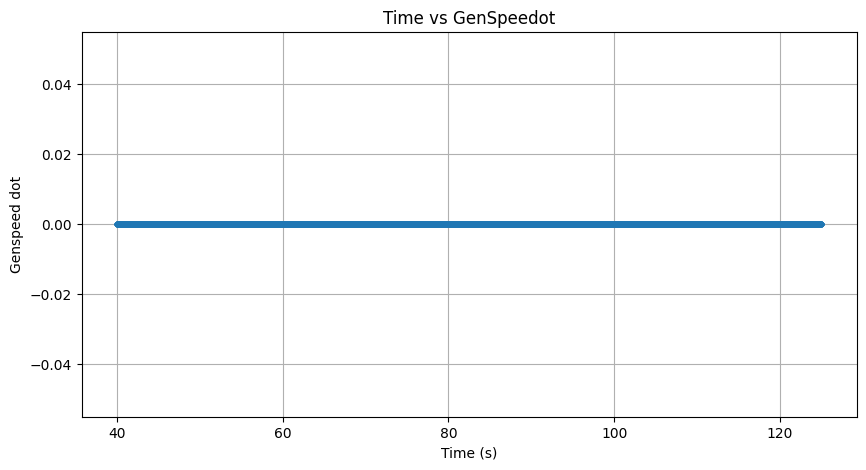

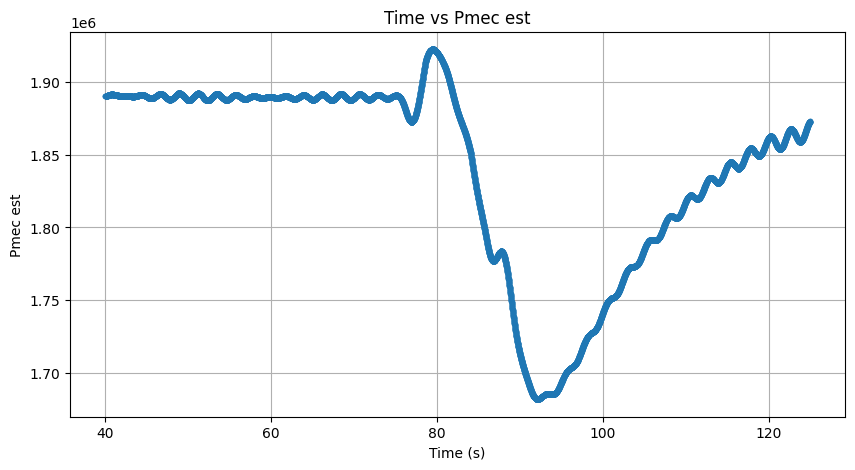

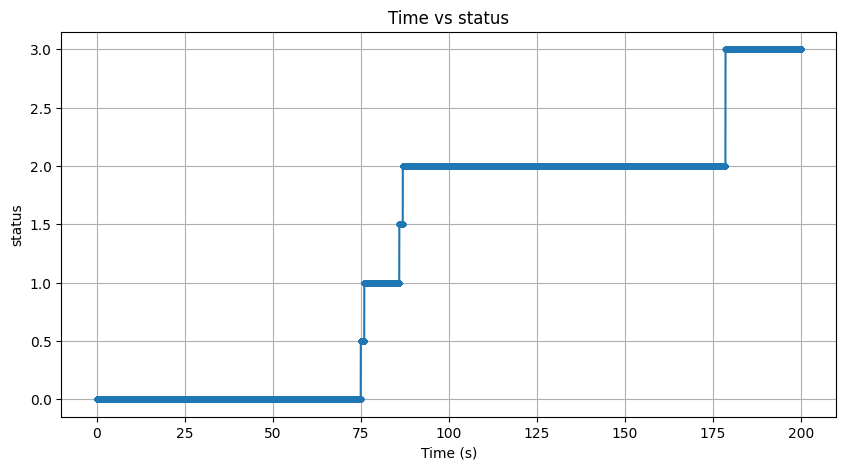

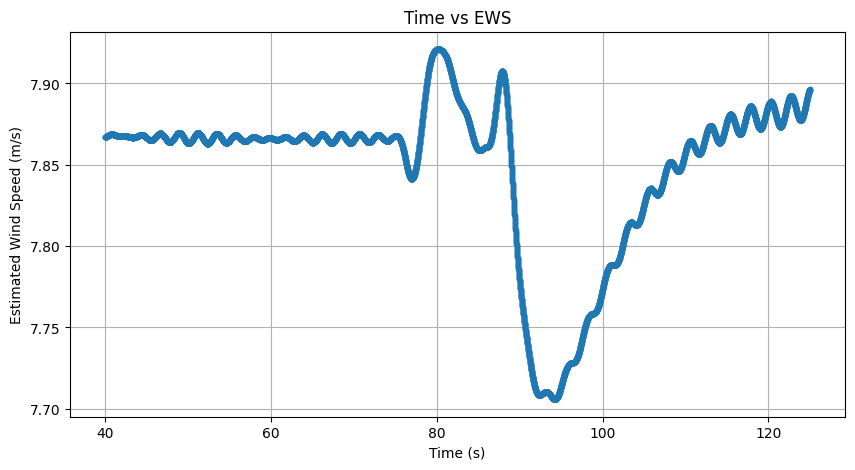

In [14]:
import matplotlib.pyplot as plt

# Ajusta nombres según tu DataFrame
time_col = 'Time'         # o 'Time_1' si se renombró
istatus_col = 'IS_status'   # o como esté en tu df.columns
Pmec_est = 'Pmec_est' 
GenSpeed_dot = 'GenSpeedF_dot'

plt.figure(figsize=(10, 5))
plt.plot(df_dbg[time_col][6400:20000], df_dbg[GenSpeed_dot][6400:20000], marker='o', linestyle='-', markersize=3)
plt.xlabel('Time (s)')
plt.ylabel('Genspeed dot')
plt.title('Time vs GenSpeedot')
#plt.xlim(1,100)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_dbg[time_col][6400:20000], df_dbg[Pmec_est][6400:20000], marker='o', linestyle='-', markersize=3)
plt.xlabel('Time (s)')
plt.ylabel('Pmec est')
plt.title('Time vs Pmec est')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_dbg[time_col], df_dbg[istatus_col], marker='o', linestyle='-', markersize=3)
plt.xlabel('Time (s)')
plt.ylabel('status')
plt.title('Time vs status')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_dbg[time_col][6400:20000], df_dbg['WE_Vw'][6400:20000], marker='o', linestyle='-', markersize=3)
plt.xlabel('Time (s)')
plt.ylabel('Estimated Wind Speed (m/s)')
plt.title('Time vs EWS')
plt.grid(True)
plt.show()

C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Tarnowski_OF/
IEA-3.4-130-RWT_Tarnowski_test.outb


C:\Users\fgarchitorena\AppData\Local\Temp\ipykernel_22408\3361000218.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


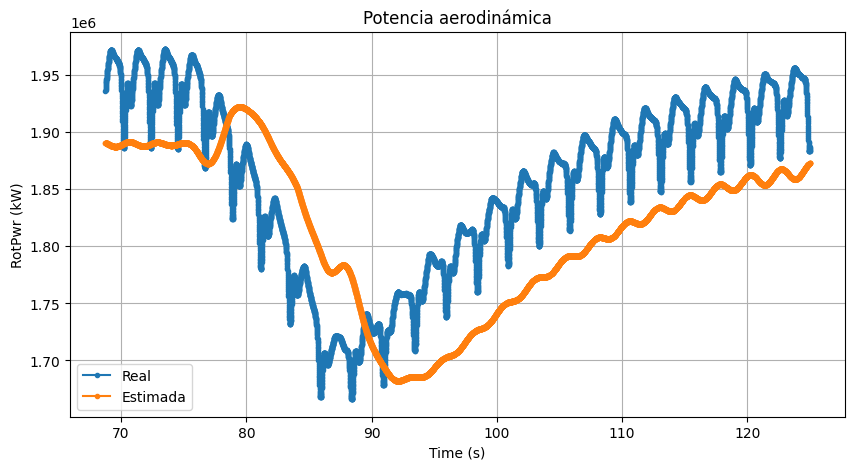

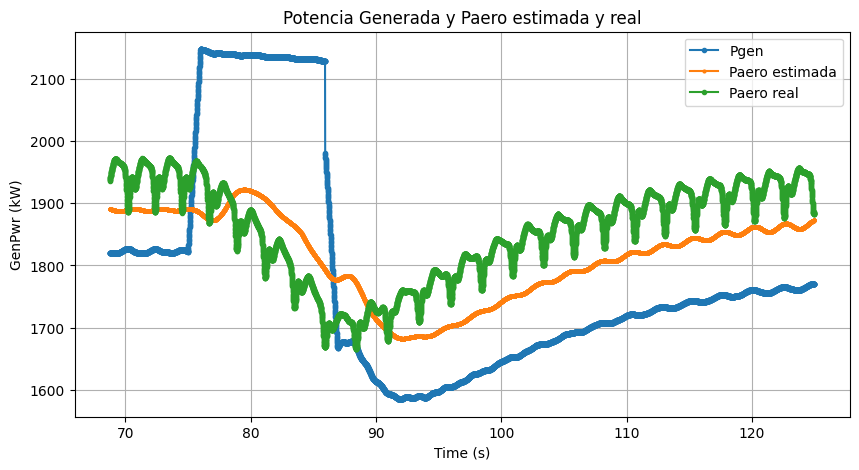

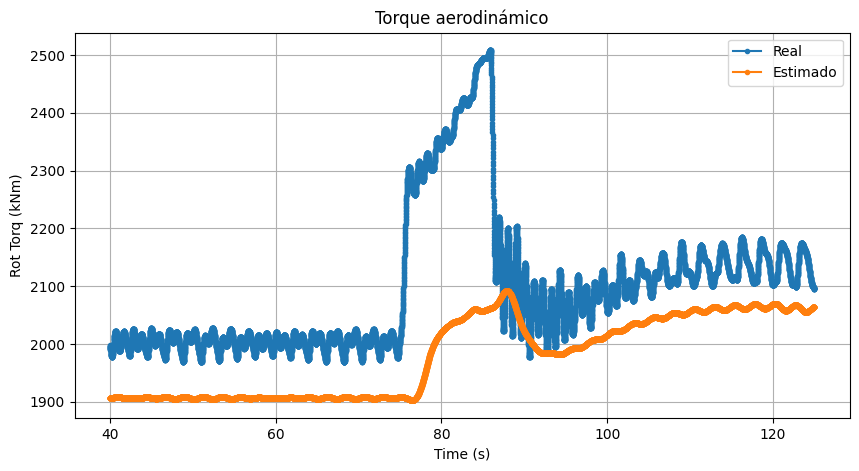

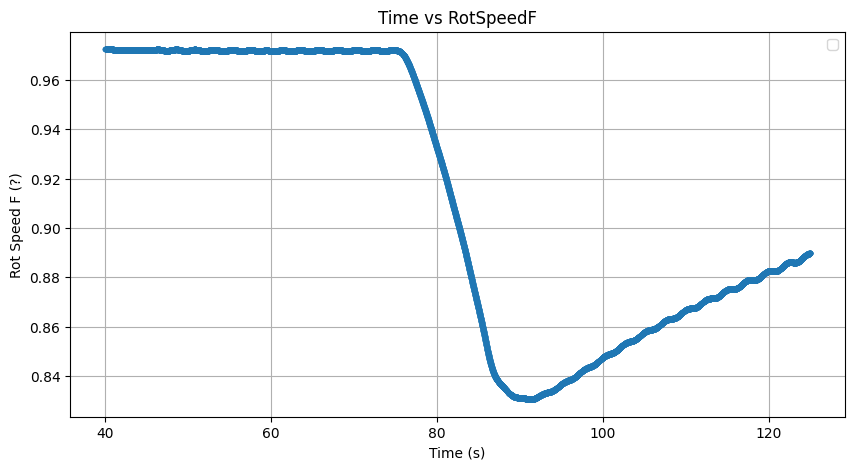

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('C:/Users/fgarchitorena/OpenFast/Design Load Cases/openfast_toolbox-main/openfast_toolbox/io')

from scipy.interpolate import LinearNDInterpolator
#from openfast_toolbox.io import FASTOutputFile
from fast_output_file import FASTOutputFile


# Get OpenFAST data - Carpeta D:/Leandro/OpenFast/proyecto_IEA/corridas/09-10-2023/
model = 'Tarnowski_test'  # flexible; rigid
U = '9.0'
sd = 'sd0'
tech = ''#'_ROSCO_SDTime'#'_TurbS'#'_prueba_ROSCO'#'_PM' ##'prueba_encendido'#'_ROSCO_SDTime_'#_PitchMan'#'_ROSCO_TurbS_'  #'_PM_'#   #'ROSCO_TurbS'#'PM_SinGen'
tech_f = ''#'_ROSCO_SDTime'#'_PM'#'ROSCO_TurbS' #'2p1_PM'#

# DLC_{model[0]}/{model}{tech}/{U}/{sd}'
print(folder)

filename = f'IEA-3.4-130-RWT_{model}.outb'#'_RTS
print(filename)

df = FASTOutputFile(folder +'/' + filename).toDataFrame()
time = np.array(list(df['Time_[s]']))


# Define el intervalo de tiempo útil
dt = 0.00625  # Intervalo de tiempo
start_index = int(60 / dt)  # Convierte 60 segundos a índices
end_index = len(time)  # O define hasta dónde quieres seleccionar

# Selecciona el tiempo útil
Useful_time_1 = time[start_index:end_index]
Wind1VelX = np.array(list(df['Wind1VelX_[m/s]']))
Wind1VelY = np.array(list(df['Wind1VelX_[m/s]']))
Wind1VelZ = np.array(list(df['Wind1VelX_[m/s]']))

RotPwr_1 = np.array(list(df['RtAeroPwr_[W]']))
GenPwr_1 = np.array(list(df['GenPwr_[kW]']))
RotSpeed_1 = np.array(list(df['RotSpeed_[rpm]']))
BldPitch1_1 = np.array(list(df['BldPitch1_[deg]']))
Edgewise_1 = np.array(list(df['RootMxb1_[kN-m]']))
Flapwise1 = np.array(list(df['RootMyb1_[kN-m]']))
Foreaft1 = np.array(list(df['TwrBsMyt_[kN-m]']))
SideSide1 = np.array(list(df['TwrBsMxt_[kN-m]']))
RotTorq = np.array(list(df['RotTorq_[kN-m]']))
Gentq = np.array(list(df['GenTq_[kN-m]']))
GenSpeed = np.array(list(df['GenSpeed_[rpm]']))

# Graficar RotPwr
plt.figure(figsize=(10, 5))
plt.plot(time[11000:20000], RotPwr_1[11000:20000], marker='o', linestyle='-', markersize=3)
plt.plot(df_dbg[time_col][11000:20000], df_dbg[Pmec_est][11000:20000], marker='o', linestyle='-', markersize=3)
plt.xlabel('Time (s)')
plt.legend(['Real','Estimada'])
plt.ylabel('RotPwr (kW)')
plt.title('Potencia aerodinámica')
plt.grid(True) 

plt.figure(figsize=(10, 5))
plt.plot(time[11000:20000], GenPwr_1[11000:20000], marker='o', linestyle='-', markersize=3)
plt.plot(df_dbg[time_col][11000:20000], df_dbg[Pmec_est][11000:20000]/1e3, marker='o', linestyle='-', markersize=2)
plt.plot(time[11000:20000], RotPwr_1[11000:20000]/1e3, marker='o', linestyle='-', markersize=3)
plt.xlabel('Time (s)')
plt.legend(['Pgen','Paero estimada', 'Paero real'])
plt.ylabel('GenPwr (kW)')
plt.title('Potencia Generada y Paero estimada y real')
plt.grid(True)  

plt.figure(figsize=(10, 5))
plt.plot(time[6400:20000], RotTorq[6400:20000], marker='o', linestyle='-', markersize=3)
plt.plot(df_dbg[time_col][6400:20000], df_dbg['Tau_r'][6400:20000]/1e3, marker='o', linestyle='-', markersize=3)
plt.xlabel('Time (s)')
plt.legend(['Real','Estimado'])
plt.ylabel('Rot Torq (kNm)')
plt.title('Torque aerodinámico')
plt.grid(True)  

plt.figure(figsize=(10, 5))
plt.plot(df_dbg[time_col][6400:20000], df_dbg['RotSpeedF'][6400:20000], marker='o', linestyle='-', markersize=3)
plt.xlabel('Time (s)')
plt.legend()
plt.ylabel('Rot Speed F (?)')
plt.title('Time vs RotSpeedF')
plt.grid(True)  



In [16]:
np.array(list(df))

array(['Time_[s]', 'Wind1VelX_[m/s]', 'BldPitch1_[deg]', 'Azimuth_[deg]',
       'RotSpeed_[rpm]', 'GenSpeed_[rpm]', 'YawPzn_[deg]', 'RotPwr_[kW]',
       'RotTorq_[kN-m]', 'LSSTipMys_[kN-m]', 'LSSTipMzs_[kN-m]',
       'LSShftFys_[kN]', 'LSShftFzs_[kN]', 'RootMyb1_[kN-m]',
       'RootMyb2_[kN-m]', 'RootMyb3_[kN-m]', 'RootMxb1_[kN-m]',
       'RootMxb2_[kN-m]', 'RootMxb3_[kN-m]', 'NcIMUTAxs_[m/s^2]',
       'NcIMUTAys_[m/s^2]', 'NcIMUTAzs_[m/s^2]', 'TwHt9ALzt_[m/s^2]',
       'QD2_TFA1_[m/s^2]', 'TwrTpTDxi_[m]', 'TwrTpTDyi_[m]',
       'TwrTpTDzi_[m]', 'TwrBsMyt_[kN-m]', 'TwrBsMxt_[kN-m]',
       'LSSTipPxs_[deg]', 'RtAeroPwr_[W]', 'GenPwr_[kW]', 'GenTq_[kN-m]'],
      dtype='<U17')

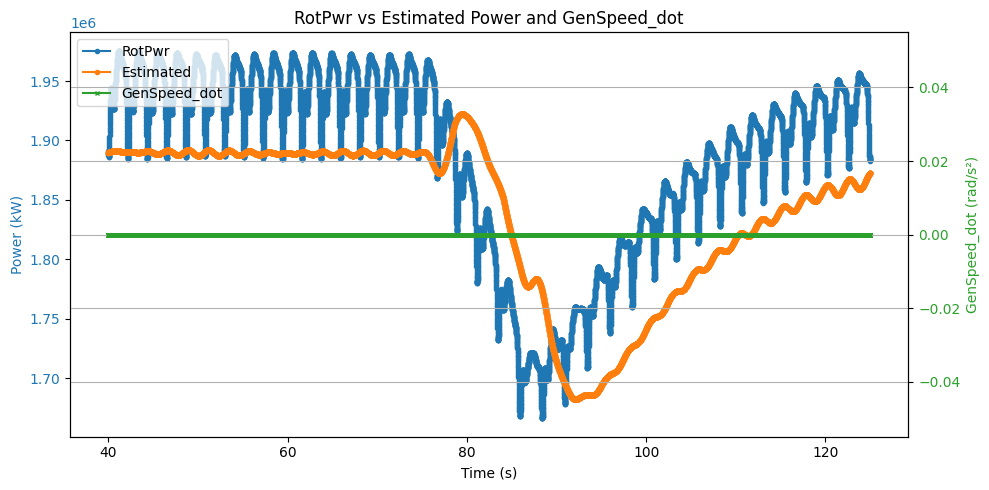

In [17]:
import matplotlib.pyplot as plt

# Rangos
i_start = 6400
i_end = 20000

# Crear figura
fig, ax1 = plt.subplots(figsize=(10, 5))

# Primer eje Y (izquierdo)
lns1 = ax1.plot(time[i_start:i_end], RotPwr_1[i_start:i_end],
                label='RotPwr', color='tab:blue', marker='o', linestyle='-', markersize=3)
lns2 = ax1.plot(df_dbg[time_col][i_start:i_end], df_dbg[Pmec_est][i_start:i_end],
                label='Estimated', color='tab:orange', marker='o', linestyle='-', markersize=3)

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Power (kW)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Segundo eje Y (derecho)
ax2 = ax1.twinx()
lns3 = ax2.plot(df_dbg[time_col][i_start:i_end], df_dbg[GenSpeed_dot][i_start:i_end]/97,
                label='GenSpeed_dot', color='tab:green', marker='x', linestyle='-', markersize=3)

ax2.set_ylabel('GenSpeed_dot (rad/s²)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Combinar leyendas
lns = lns1 + lns2 + lns3
labels = [l.get_label() for l in lns]
ax1.legend(lns, labels, loc='upper left')

plt.title('RotPwr vs Estimated Power and GenSpeed_dot')
plt.grid(True)
plt.tight_layout()
plt.show()
